# Code for synthetic experiment

In [1]:
from scipy.stats import gamma

import warnings

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scores.continuous import tw_quantile_score, mse, mae, quantile_score
from scores.probability import interval_tw_crps_for_ensemble, brier_score
from scores.processing import broadcast_and_match_nan
from scores.plotdata import murphy_score, murphy_thetas

from scores.stats.statistical_tests import diebold_mariano


import tte

<details>
<summary>
    <b>Package details</b>
    
Click here to see output of `!pip list`. This will let you see the versions of the packages used at the time when  the notebook was archived.</summary>
  

Package                           Version
--------------------------------- -----------
alabaster                         0.7.16
alembic                           1.8.1
annotated-types                   0.6.0
anyio                             4.2.0
argon2-cffi                       21.3.0
argon2-cffi-bindings              21.2.0
asciitree                         0.3.3
astroid                           3.2.4
asttokens                         2.0.5
async-generator                   1.10
async-lru                         2.0.4
attrs                             23.1.0
Babel                             2.11.0
bandit                            1.7.9
beautifulsoup4                    4.12.3
black                             24.4.2
bleach                            4.1.0
blinker                           1.6.2
bokeh                             3.4.1
bom-jive                          1.24.5
Bottleneck                        1.3.7
branca                            0.6.0
Brotli                            1.0.9
cached-property                   1.5.2
cachetools                        5.3.3
Cartopy                           0.22.0
certifi                           2025.10.5
certipy                           0.1.3
cffi                              1.16.0
cfgv                              3.4.0
cftime                            1.6.2
charset-normalizer                3.3.2
click                             8.1.7
click-plugins                     1.1.1
cligj                             0.7.2
cloudpickle                       3.0.0
colorama                          0.4.6
comm                              0.2.1
commonmark                        0.9.1
contourpy                         1.2.0
coverage                          7.2.2
cryptography                      43.0.0
cx-Oracle                         8.3.0
cycler                            0.11.0
cytoolz                           0.12.2
dask                              2024.5.0
dask-expr                         1.1.0
debugpy                           1.6.7
decorator                         5.1.1
defusedxml                        0.7.1
dill                              0.3.8
distlib                           0.3.8
distributed                       2024.5.0
docopt                            0.6.2
docutils                          0.18.1
entrypoints                       0.4
eta_verification                  0.19.2
executing                         0.8.3
fasteners                         0.16.3
fastjsonschema                    2.16.2
filelock                          3.13.1
fiona                             1.9.6
flake8                            7.0.0
flexcache                         0.3
flexparser                        0.4
folium                            0.14.0
fonttools                         4.51.0
fsspec                            2024.6.1
future                            0.18.3
GDAL                              3.9.2
GeoAlchemy2                       0.15.2
geopandas                         0.14.2
gitdb                             4.0.7
GitPython                         3.1.43
greenlet                          3.0.1
h5py                              3.11.0
HeapDict                          1.0.1
identify                          2.5.5
idna                              3.7
imagesize                         1.4.1
importlib-metadata                7.0.1
iniconfig                         1.1.1
ipykernel                         6.28.0
ipython                           8.25.0
ipython-genutils                  0.2.0
ipywidgets                        8.1.2
isodate                           0.6.1
isort                             5.13.2
jedi                              0.19.1
Jinja2                            3.1.4
jive_adam                         0.4.1
jive_aifs_warnings                0.3.0
jive_ehf                          0.9.1
jive_gfe                          0.12.8
joblib                            1.4.2
json5                             0.9.6
jsonschema                        4.19.2
jsonschema-specifications         2023.7.1
jupyter                           1.0.0
jupyter_client                    7.4.9
jupyter-console                   6.6.3
jupyter-contrib-core              0.4.0
jupyter-contrib-nbextensions      0.7.0
jupyter_core                      5.7.2
jupyter-events                    0.10.0
jupyter-highlight-selected-word   0.2.0
jupyter-kernel-gateway            2.5.0
jupyter-latex-envs                1.4.6
jupyter-lsp                       2.2.0
jupyter-nbextensions-configurator 0.6.1
jupyter_server                    2.14.1
jupyter_server_terminals          0.4.4
jupyter-telemetry                 0.1.0
jupyterhub                        2.3.1
jupyterhub_saml2                  0.9.0
jupyterlab                        4.0.11
jupyterlab_code_formatter         3.0.2
jupyterlab_execute_time           3.1.2
jupyterlab-pygments               0.1.2
jupyterlab_server                 2.25.1
jupyterlab-widgets                3.0.10
kaleido                           0.2.1
kiwisolver                        1.4.4
llvmlite                          0.44.0
lmdb                              1.4.1
locket                            1.0.0
lxml                              5.3.0
lz4                               4.3.2
Mako                              1.2.3
mapclassify                       2.5.0
markdown-it-py                    3.0.0
MarkupSafe                        2.1.3
matplotlib                        3.9.2
matplotlib-inline                 0.1.6
mccabe                            0.7.0
mdit-py-plugins                   0.4.1
mdurl                             0.1.0
memory-profiler                   0.61.0
MetPy                             1.6.3
mistune                           2.0.4
mkl_fft                           1.3.10
mkl_random                        1.2.7
mkl-service                       2.4.0
msgpack                           1.0.3
mypy-extensions                   1.0.0
myst-parser                       3.0.1
nbclassic                         1.1.0
nbclient                          0.8.0
nbconvert                         7.10.0
nbformat                          5.9.2
nest-asyncio                      1.6.0
netCDF4                           1.7.1
networkx                          3.3
nodeenv                           1.7.0
notebook                          6.5.7
notebook_shim                     0.2.3
numba                             0.61.2
numcodecs                         0.12.1
numexpr                           2.8.7
numpy                             1.26.4
oauthlib                          3.2.2
oracledb                          2.1.1
overrides                         7.4.0
packaging                         24.1
pamela                            1.0.0
pandas                            2.1.4
pandocfilters                     1.5.0
parso                             0.8.3
partd                             1.4.1
pathspec                          0.10.3
patsy                             0.5.6
pbr                               5.6.0
pep8                              1.7.1
pexpect                           4.8.0
pillow                            10.4.0
Pint                              0.24.4
pip                               24.2
platformdirs                      3.10.0
plotly                            5.22.0
pluggy                            1.0.0
ply                               3.11
pooch                             1.8.2
pre_commit                        3.8.0
prometheus-client                 0.14.1
prompt-toolkit                    3.0.43
psutil                            5.9.0
psycopg2                          2.9.9
ptyprocess                        0.7.0
pure-eval                         0.2.2
pyarrow                           17.0.0
pycodestyle                       2.11.1
pycparser                         2.21
pycurl                            7.45.3
pydantic                          2.8.2
pydantic_core                     2.20.1
pyflakes                          3.2.0
Pygments                          2.15.1
PyJWT                             2.8.0
pylint                            3.2.2
pyOpenSSL                         24.2.1
pyparsing                         3.1.2
pyproj                            3.6.1
PyQt5                             5.15.10
PyQt5-sip                         12.13.0
pyshp                             2.3.1
PySocks                           1.7.1
pytest                            7.4.4
pytest-cov                        4.1.0
pytest-runner                     6.0.0
python-dateutil                   2.9.0.post0
python-json-logger                2.0.7
python3-saml                      1.9.0
pytz                              2024.1
PyYAML                            6.0.1
pyzmq                             25.1.2
qtconsole                         5.5.1
QtPy                              2.4.1
recommonmark                      0.6.0
referencing                       0.30.2
requests                          2.32.3
rfc3339-validator                 0.1.4
rfc3986-validator                 0.1.1
rich                              10.16.2
rpds-py                           0.10.6
Rtree                             1.0.1
ruamel.yaml                       0.18.6
ruamel.yaml.clib                  0.2.8
scikit-learn                      1.5.1
scipy                             1.13.1
scores                            2.2.0
scoringrules                      0.8.0
seaborn                           0.13.2
Send2Trash                        1.8.2
setuptools                        72.1.0
shapely                           2.0.6
sip                               6.7.12
six                               1.16.0
smmap                             4.0.0
sniffio                           1.3.0
snowballstemmer                   2.2.0
sortedcontainers                  2.4.0
soupsieve                         2.5
Sphinx                            7.3.7
sphinx_rtd_theme                  2.0.0
sphinxcontrib-applehelp           1.0.2
sphinxcontrib-devhelp             1.0.2
sphinxcontrib-htmlhelp            2.0.0
sphinxcontrib-jquery              4.1
sphinxcontrib-jsmath              1.0.1
sphinxcontrib-qthelp              1.0.3
sphinxcontrib-serializinghtml     1.1.10
SQLAlchemy                        1.4.49
stack-data                        0.2.0
statsmodels                       0.14.2
stevedore                         5.3.0
tblib                             1.7.0
tenacity                          8.2.3
terminado                         0.17.1
threadpoolctl                     3.5.0
tinycss2                          1.2.1
toml                              0.10.2
tomli                             2.0.1
tomlkit                           0.11.1
toolz                             0.12.0
tornado                           6.4.1
traitlets                         5.14.3
typing_extensions                 4.11.0
tzdata                            2023.3
ukkonen                           1.0.1
unicodedata2                      15.1.0
urllib3                           2.2.2
virtualenv                        20.26.1
wcwidth                           0.2.5
webencodings                      0.5.1
websocket-client                  1.8.0
wheel                             0.43.0
widgetsnbextension                4.0.10
xarray                            2024.7.0
xgboost                           2.1.1
xmlsec                            1.3.14
xmltodict                         0.13.0
xyzservices                       2022.9.0
zarr                              2.18.2
zict                              3.0.0
zipp                              3.17.0


</details>

In [2]:
FCST_NAMES = [
    'LowInfoLucy',
    'ModInfoMuli',
    'HighInfoHannah',
    'PessimisticPenny',
    'OptimisticOmar'
]

In [3]:
def pdf_points(xs, alpha, beta, loc):
    """
    Gets the points (x,y) for plotting the graph of the PDF of the gamma distribution
    with shape parameter `alpha`, rate parameter `beta` and location parameter `loc`.
    
    `xs` is a 1D array or list of x values to be plotted.
    
    Returns a type of 1D arrays for the x and y values. The returned x values
    has all values in `xs` plus `loc`.
    """
    xs_to_loc = [x for x in xs if x < loc] + [loc]
    xs_from_loc = [loc] + [x for x in xs if x > loc]

    ys_to_loc = [0 for x in xs_to_loc]
    ys_from_loc = list(gamma.pdf(xs_from_loc, alpha, loc=loc, scale=1/beta))
    
    xs_out = xs_to_loc + xs_from_loc
    ys_out = ys_to_loc + ys_from_loc
    
    
    return xs_out, ys_out


def array_to_xarray(array):
    """
    Args: 
        array: 1D numpy array
    Returns:
        data array, with 'case' dimension
    """
    da = xr.DataArray(
        data=array,
        dims=['case'],
        coords={'case': np.arange(len(array))}
    )
    return da


def test_for_all_pairs(fcst_scores, confidence_level=0.95):
    """
    Given an n-tuple of forecast scores, each a 1D xr.DataArray of same length,
    prints out combinations for which Diebold Mariano test for equal predictive performance
    is accepted (i.e., the confidence interval for the difference of mean scores includes 0).
    
    'All tests completed' is printed when all tests have been conducted.
    """
    # make forecaster pairs
    for i in range(len(fcst_scores)):
        for j in range(i+1, len(fcst_scores)):
            # calculate the difference in scores
            scores_diff = fcst_scores[i] - fcst_scores[j]
            scores_diff = scores_diff.assign_coords(h=1).expand_dims('h')
            # Do the Diebold Mariano test
            dm_test_stats = diebold_mariano(scores_diff, "h", "h", confidence_level=confidence_level)
            accept_null_hypothesis = bool(dm_test_stats['ci_upper'] * dm_test_stats['ci_lower'] <= 0)
            if accept_null_hypothesis:
                print(f'null hypothesis accepted for combination {i,j}')
    print('All tests completed')

## Generate the random variables

In [4]:
# random state
rndst=41

# number of forecast cases
n = 10000

# shape parameters for gamma distributions of X, Y, Z
alpha_x = array_to_xarray(np.repeat(3, n))
alpha_y = array_to_xarray(np.repeat(2, n))
alpha_z = array_to_xarray(np.repeat(1, n))

# rate parameter for gamma distributions
beta = 1
beta_pessimist = beta * 2
beta_optimist = beta / 3

# random variates - these are the observations
x = gamma.rvs(alpha_x, scale=1/beta, size=n, random_state=rndst)
y = gamma.rvs(alpha_y, scale=1/beta, size=n, random_state=rndst)
z = gamma.rvs(alpha_z, scale=1/beta, size=n, random_state=rndst)

x = array_to_xarray(x)
y = array_to_xarray(y)
z = array_to_xarray(z)


# summed parameters and random variates
t = x + y + z  # observed time-to-event
alpha_xyz = alpha_x + alpha_y + alpha_z  # LowInfoLucy's shape parameter
alpha_yz = alpha_y + alpha_z  # ModInfoMuli's shape parameter



## Results for Table 1

In [5]:
# CRPS for each forecaster
crps_low = tte.crps_gamma(alpha_xyz, beta, 0, t)
crps_mod = tte.crps_gamma(alpha_yz, beta, x, t)
crps_high = tte.crps_gamma(alpha_z, beta, x + y, t)
crps_pessimist = tte.crps_gamma(alpha_z, beta_pessimist, x + y, t)
crps_optimist = tte.crps_gamma(alpha_z, beta_optimist, x + y, t)

fcst_scores = (crps_low, crps_mod, crps_high, crps_pessimist, crps_optimist)

test_for_all_pairs(fcst_scores)

crps_results = np.array([float(x.mean()) for x in fcst_scores])
crps_results

All tests completed


array([1.37419677, 0.94856277, 0.49514418, 0.57639499, 1.00093354])

In [6]:
# LogS for each forecaster
logs_low = tte.log_score_gamma(alpha_xyz, beta, 0, t)
logs_mod = tte.log_score_gamma(alpha_yz, beta, x, t)
logs_high = tte.log_score_gamma(alpha_z, beta, x + y, t)
logs_pessimist = tte.log_score_gamma(alpha_z, beta_pessimist, x + y, t)
logs_optimist = tte.log_score_gamma(alpha_z, beta_optimist, x + y, t)

fcst_scores = (logs_low, logs_mod, logs_high, logs_pessimist, logs_optimist)

test_for_all_pairs(fcst_scores)

logs_results = np.array([float(x.mean()) for x in fcst_scores])
logs_results

All tests completed


array([2.27479338, 1.85828028, 0.99160114, 1.2900551 , 1.429146  ])

In [7]:
# LinS for each forecaster
lins_low = tte.linear_score_gamma(alpha_xyz, beta, 0, t)
lins_mod = tte.linear_score_gamma(alpha_yz, beta, x, t)
lins_high = tte.linear_score_gamma(alpha_z, beta, x + y, t)
lins_pessimist = tte.linear_score_gamma(alpha_z, beta_pessimist, x + y, t)
lins_optimist = tte.linear_score_gamma(alpha_z, beta_optimist, x + y, t)

fcst_scores = (lins_low, lins_mod, lins_high, lins_pessimist, lins_optimist)

test_for_all_pairs(fcst_scores)

lins_results = np.array([float(x.mean()) for x in fcst_scores])
lins_results

All tests completed


array([-0.12219662, -0.18641271, -0.50177152, -0.6695877 , -0.25051847])

In [8]:
table1_results = pd.DataFrame.from_records(
    data=[
        crps_results,
        logs_results,
        lins_results,
    ],
    columns=FCST_NAMES,
    index=['CRPS', 'LogS', 'LinS']
).reset_index().rename(columns={'index': 'scoring rule'}).round(3)

table1_results

,scoring rule,LowInfoLucy,ModInfoMuli,HighInfoHannah,PessimisticPenny,OptimisticOmar
0,CRPS,1.374,0.949,0.495,0.576,1.001
1,LogS,2.275,1.858,0.992,1.290,1.429
2,LinS,-0.122,-0.186,-0.502,-0.670,-0.251


## Code for Figure 1

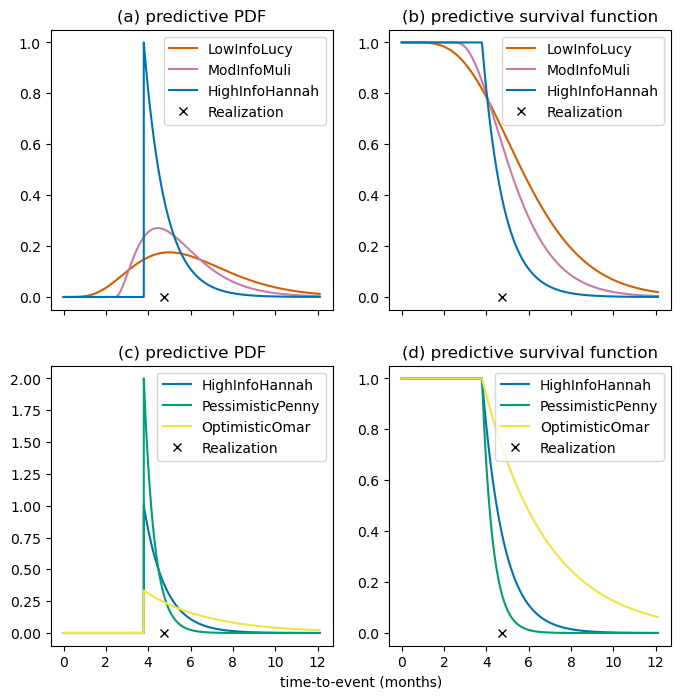

In [9]:
# example of a forecast pdfs
case = 0
X = 2.45
Y = 1.34
Z = 0.94
T = X + Y + Z

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 8), sharex=True)

cp = ['#d55e00', '#cc79a7', '#0072b2', '#009e73', '#f0e442']  # color pallette
linwid = 1.5  # line width
opa = 1  # opacity

max_x = 12.1
xs = np.linspace(0, max_x, 500)

# PFD of first three forecasters
pdf_points_mod = pdf_points(xs, alpha_yz.values[case], beta, X)
pdf_points_high = pdf_points(xs, alpha_z.values[case], beta, X + Y)

ax1.plot(xs, gamma.pdf(xs, alpha_xyz.values[case], scale=1/beta),
         lw=linwid, alpha=opa, label=FCST_NAMES[0], color=cp[0])
ax1.plot(pdf_points_mod[0], pdf_points_mod[1],
         lw=linwid, alpha=opa, label=FCST_NAMES[1], color=cp[1])
ax1.plot(pdf_points_high[0], pdf_points_high[1],
         lw=linwid, alpha=opa, label=FCST_NAMES[2], color=cp[2])
ax1.plot(T, 0, 'kx', lw=2, alpha=1, label='Realization')

# Survival function of first three forecasters
ax2.plot(xs, gamma.sf(xs, alpha_xyz.values[case], scale=1/beta), 
         lw=linwid, alpha=opa, label=FCST_NAMES[0], color=cp[0])
ax2.plot(xs, gamma.sf(xs - X, alpha_yz.values[case], scale=1/beta), 
         lw=linwid, alpha=opa, label=FCST_NAMES[1], color=cp[1])
ax2.plot(xs, gamma.sf(xs - X - Y, alpha_z.values[case], scale=1/beta), 
         lw=linwid, alpha=opa, label=FCST_NAMES[2], color=cp[2])
ax2.plot(T, 0, 'kx', lw=2, alpha=1, label='Realization')


# PFD of last three forecasters
pdf_points_pessimist = pdf_points(xs, alpha_z.values[case], beta_pessimist, X + Y)
pdf_points_optimist = pdf_points(xs, alpha_z.values[case], beta_optimist, X + Y)

ax3.plot(pdf_points_high[0], pdf_points_high[1],
         lw=linwid, alpha=opa, label=FCST_NAMES[2], color=cp[2])
ax3.plot(pdf_points_pessimist[0], pdf_points_pessimist[1], 
         lw=linwid, alpha=opa, label=FCST_NAMES[3], color=cp[3])
ax3.plot(pdf_points_optimist[0], pdf_points_optimist[1], 
         lw=linwid, alpha=opa, label=FCST_NAMES[4], color=cp[4])
ax3.plot(T, 0, 'kx', lw=2, alpha=1, label='Realization')

# Survival function of last three forecasters
ax4.plot(xs, gamma.sf(xs - X - Y, alpha_z.values[case], scale=1/beta),
         lw=linwid, alpha=opa, label=FCST_NAMES[2],color=cp[2])
ax4.plot(xs, gamma.sf(xs - X - Y, alpha_z.values[case], scale=1/beta_pessimist), 
         lw=linwid, alpha=opa, label=FCST_NAMES[3], color=cp[3])
ax4.plot(xs, gamma.sf(xs - X - Y, alpha_z.values[case], scale=1/beta_optimist), 
         lw=linwid, alpha=opa, label=FCST_NAMES[4], color=cp[4])
ax4.plot(T, 0, 'kx', lw=2, alpha=1, label='Realization')

ax1.legend()
ax2.legend()
ax3.legend()
ax4.legend()

xticks = [0, 2, 4, 6, 8, 10, 12]
ax1.set_xticks(xticks)


ax1.set_title('(a) predictive PDF')
ax2.set_title('(b) predictive survival function')
ax3.set_title('(c) predictive PDF')
ax4.set_title('(d) predictive survival function')

# Add a "big axis" to the figure to hold the common x-label
# This axis is invisible and only serves to place the label
fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)

# Set the common x-axis label
plt.xlabel("time-to-event (months)")

plt.show()

## Results for Table 2

In [10]:
# c-index with s=2

s = 2
tau = 10000
fcst_low = gamma.cdf(s, alpha_xyz, scale=1/beta)
fcst_mod = gamma.cdf(s, alpha_yz, scale=1/beta, loc=x)
fcst_high = gamma.cdf(s, alpha_z, scale=1/beta, loc=x+y)
fcst_pessimist = gamma.cdf(s, alpha_z, scale=1/beta_pessimist, loc=x+y)
fcst_optimist = gamma.cdf(s, alpha_z, scale=1/beta_optimist, loc=x+y)

c_index_low = tte.c_index(fcst_low, t, tau)
c_index_mod = tte.c_index(fcst_mod, t, tau)
c_index_high = tte.c_index(fcst_high, t, tau)
c_index_pessimist = tte.c_index(fcst_pessimist, t, tau)
c_index_optimist = tte.c_index(fcst_optimist, t, tau)

cindex2_results = np.array([c_index_low, c_index_mod, c_index_high, c_index_pessimist, c_index_optimist])
cindex2_results

array([0.5       , 0.64606357, 0.54722894, 0.54722894, 0.54722894])

In [11]:
# c-index with s=10

s = 10
tau = 10000
fcst_low = gamma.cdf(s, alpha_xyz, scale=1/beta)
fcst_mod = gamma.cdf(s, alpha_yz, scale=1/beta, loc=x)
fcst_high = gamma.cdf(s, alpha_z, scale=1/beta, loc=x+y)
fcst_pessimist = gamma.cdf(s, alpha_z, scale=1/beta_pessimist, loc=x+y)
fcst_optimist = gamma.cdf(s, alpha_z, scale=1/beta_optimist, loc=x+y)

c_index_low = tte.c_index(fcst_low, t, tau)
c_index_mod = tte.c_index(fcst_mod, t, tau)
c_index_high = tte.c_index(fcst_high, t, tau)
c_index_pessimist = tte.c_index(fcst_pessimist, t, tau)
c_index_optimist = tte.c_index(fcst_optimist, t, tau)

cindex10_results = np.array([c_index_low, c_index_mod, c_index_high, c_index_pessimist, c_index_optimist])
cindex10_results

array([0.5       , 0.75031646, 0.87948496, 0.87948496, 0.87948496])

In [12]:
# AUC, s=2

s = 2

fcst_low = gamma.cdf(s, alpha_xyz, scale=1/beta)
fcst_mod = gamma.cdf(s, alpha_yz, scale=1/beta, loc=x)
fcst_high = gamma.cdf(s, alpha_z, scale=1/beta, loc=x+y)
fcst_pessimist = gamma.cdf(s, alpha_z, scale=1/beta_pessimist, loc=x+y)
fcst_optimist = gamma.cdf(s, alpha_z, scale=1/beta_optimist, loc=x+y)

auc_s_low = tte.auc_s(fcst_low, t, s)
auc_s_mod = tte.auc_s(fcst_mod, t, s)
auc_s_high = tte.auc_s(fcst_high, t, s)
auc_s_pessimist = tte.auc_s(fcst_pessimist, t, s)
auc_s_optimist = tte.auc_s(fcst_optimist, t, s)

auc_2_results = np.array([auc_s_low, auc_s_mod, auc_s_high, auc_s_pessimist, auc_s_optimist])
auc_2_results

array([0.5       , 0.95503318, 0.99221504, 0.99221504, 0.99221504])

In [13]:
# AUC, s=10

s = 10

fcst_low = gamma.cdf(s, alpha_xyz, scale=1/beta)
fcst_mod = gamma.cdf(s, alpha_yz, scale=1/beta, loc=x)
fcst_high = gamma.cdf(s, alpha_z, scale=1/beta, loc=x+y)
fcst_pessimist = gamma.cdf(s, alpha_z, scale=1/beta_pessimist, loc=x+y)
fcst_optimist = gamma.cdf(s, alpha_z, scale=1/beta_optimist, loc=x+y)

auc_s_low = tte.auc_s(fcst_low, t, s)
auc_s_mod = tte.auc_s(fcst_mod, t, s)
auc_s_high = tte.auc_s(fcst_high, t, s)
auc_s_pessimist = tte.auc_s(fcst_pessimist, t, s)
auc_s_optimist = tte.auc_s(fcst_optimist, t, s)

auc_10_results = np.array([auc_s_low, auc_s_mod, auc_s_high, auc_s_pessimist, auc_s_optimist])
auc_10_results

array([0.5       , 0.86457125, 0.95941287, 0.95941287, 0.95941287])

In [14]:
table2_results = pd.DataFrame.from_records(
    data=[
        cindex2_results,
        cindex10_results,
        auc_2_results,
        auc_10_results
    ],
    columns=FCST_NAMES,
    index=['c-index (s=2)', 'c-index (s=10)', 'AUC_s (s=2)', 'AUC_s (s=10)']
).reset_index().rename(columns={'index': 'discrimination index'}).round(3)

table2_results

,discrimination index,LowInfoLucy,ModInfoMuli,HighInfoHannah,PessimisticPenny,OptimisticOmar
0,c-index (s=2),0.5,0.646,0.547,0.547,0.547
1,c-index (s=10),0.5,0.750,0.879,0.879,0.879
2,AUC_s (s=2),0.5,0.955,0.992,0.992,0.992
3,AUC_s (s=10),0.5,0.865,0.959,0.959,0.959


## Reults for Table 3 - by row

In [15]:
# mean value forecast
mean_low = gamma.mean(alpha_xyz.values[0], scale=1/beta, loc=0)
mean_mod = gamma.mean(alpha_yz.values[0], scale=1/beta, loc=X)
mean_high = gamma.mean(alpha_z.values[0], scale=1/beta, loc=X+Y)
mean_pessimist = gamma.mean(alpha_z.values[0], scale=1/beta_pessimist, loc=X+Y)
mean_optimist = gamma.mean(alpha_z.values[0], scale=1/beta_optimist, loc=X+Y)

example_mean = [mean_low, mean_mod, mean_high, mean_pessimist, mean_optimist]
example_mean

[6.0, 5.45, 4.79, 4.29, 6.79]

In [16]:
# median value forecast
median_low = gamma.median(alpha_xyz.values[0], scale=1/beta, loc=0)
median_mod = gamma.median(alpha_yz.values[0], scale=1/beta, loc=X)
median_high = gamma.median(alpha_z.values[0], scale=1/beta, loc=X+Y)
median_pessimist = gamma.median(alpha_z.values[0], scale=1/beta_pessimist, loc=X+Y)
median_optimist = gamma.median(alpha_z.values[0], scale=1/beta_optimist, loc=X+Y)

example_median = [median_low, median_mod, median_high, median_pessimist, median_optimist]
example_median

[5.67016118871207,
 5.124060313723559,
 4.483147180559945,
 4.136573590279973,
 5.869441541679837]

In [17]:
# 0.1-quantile (10th percentile) value forecast
level = 0.1

q_low = gamma.ppf(level, alpha_xyz.values[0], scale=1/beta, loc=0)
q_mod = gamma.ppf(level, alpha_yz.values[0], scale=1/beta, loc=X)
q_high = gamma.ppf(level, alpha_z.values[0], scale=1/beta, loc=X+Y)
q_pessimist = gamma.ppf(level, alpha_z.values[0], scale=1/beta_pessimist, loc=X+Y)
q_optimist = gamma.ppf(level, alpha_z.values[0], scale=1/beta_optimist, loc=X+Y)

example_q10 = [q_low, q_mod, q_high, q_pessimist, q_optimist]
example_q10

[3.151898029792162,
 3.5520653282493218,
 3.8953605156578264,
 3.8426802578289134,
 4.1060815469734795]

In [18]:
# 0.25-quantile (25th percentile) value forecast
level = 0.25

q_low = gamma.ppf(level, alpha_xyz.values[0], scale=1/beta, loc=0)
q_mod = gamma.ppf(level, alpha_yz.values[0], scale=1/beta, loc=X)
q_high = gamma.ppf(level, alpha_z.values[0], scale=1/beta, loc=X+Y)
q_pessimist = gamma.ppf(level, alpha_z.values[0], scale=1/beta_pessimist, loc=X+Y)
q_optimist = gamma.ppf(level, alpha_z.values[0], scale=1/beta_optimist, loc=X+Y)

example_q25 = [q_low, q_mod, q_high, q_pessimist, q_optimist]
example_q25

[4.219209383067897,
 4.177299417860519,
 4.077682072451781,
 3.9338410362258904,
 4.653046217355342]

In [19]:
# 0.75-quantile (75th percentile) value forecast
level = 0.75

q_low = gamma.ppf(level, alpha_xyz.values[0], scale=1/beta, loc=0)
q_mod = gamma.ppf(level, alpha_yz.values[0], scale=1/beta, loc=X)
q_high = gamma.ppf(level, alpha_z.values[0], scale=1/beta, loc=X+Y)
q_pessimist = gamma.ppf(level, alpha_z.values[0], scale=1/beta_pessimist, loc=X+Y)
q_optimist = gamma.ppf(level, alpha_z.values[0], scale=1/beta_optimist, loc=X+Y)

example_q75 = [q_low, q_mod, q_high, q_pessimist, q_optimist]
example_q75

[7.422701835520088,
 6.370402060292561,
 5.176294361119891,
 4.483147180559945,
 7.9488830833596715]

## Results for Table 4

In [20]:
# mean value forecast, scored by MSE
mean_low = gamma.mean(alpha_xyz, scale=1/beta, loc=0)
mean_mod = gamma.mean(alpha_yz, scale=1/beta, loc=x)
mean_high = gamma.mean(alpha_z, scale=1/beta, loc=x+y)
mean_pessimist = gamma.mean(alpha_z, scale=1/beta_pessimist, loc=x+y)
mean_optimist = gamma.mean(alpha_z, scale=1/beta_optimist, loc=x+y)

mean_fcsts = [mean_low, mean_mod, mean_high, mean_pessimist, mean_optimist]

fcst_scores = [
    mse(array_to_xarray(fcst), t, preserve_dims='all') for fcst in mean_fcsts
]

test_for_all_pairs(fcst_scores)

mse_mean_results = np.array([float(x.mean()) for x in fcst_scores])
mse_mean_results

All tests completed


array([6.18878131, 3.06640322, 0.98731128, 1.22891242, 5.02090672])

In [21]:
# mean value forecast, scored by MAE

fcst_scores = [
    mae(array_to_xarray(fcst), t, preserve_dims='all') for fcst in mean_fcsts
]

test_for_all_pairs(fcst_scores)

mae_mean_results = np.array([float(x.mean()) for x in fcst_scores])
mae_mean_results

All tests completed


array([1.95398367, 1.35894425, 0.72934114, 0.70590796, 2.10566417])

In [22]:
# median value forecast, scored by MAE
median_low = gamma.median(alpha_xyz, scale=1/beta, loc=0)
median_mod = gamma.median(alpha_yz, scale=1/beta, loc=x)
median_high = gamma.median(alpha_z, scale=1/beta, loc=x+y)
median_pessimist = gamma.median(alpha_z, scale=1/beta_pessimist, loc=x+y)
median_optimist = gamma.median(alpha_z, scale=1/beta_optimist, loc=x+y)

median_fcsts = [median_low, median_mod, median_high, median_pessimist, median_optimist]

fcst_scores = [
    mae(array_to_xarray(fcst), t, preserve_dims='all') for fcst in median_fcsts
]

test_for_all_pairs(fcst_scores)

mae_median_results = np.array([float(x.mean()) for x in fcst_scores])
mae_median_results

null hypothesis accepted for combination (1, 4)
All tests completed


array([1.93887783, 1.3349567 , 0.6857845 , 0.75350491, 1.33046835])

In [23]:
# quantile forecast, scored by quantile loss (90th percentile)

q_level = 0.9
q_low = gamma.ppf(q_level, alpha_xyz, scale=1/beta, loc=0)
q_med = gamma.ppf(q_level, alpha_yz, scale=1/beta, loc=x)
q_high = gamma.ppf(q_level, alpha_z, scale=1/beta, loc=x+y)
q_pessimist = gamma.ppf(q_level, alpha_z, scale=1/beta_pessimist, loc=x+y)
q_optimist = gamma.ppf(q_level, alpha_z, scale=1/beta_optimist, loc=x+y)

q90_fcsts = [q_low, q_med, q_high, q_pessimist, q_optimist]

fcst_scores = [
    quantile_score(array_to_xarray(fcst), t, q_level, preserve_dims=['case']) for fcst in q90_fcsts
]

test_for_all_pairs(fcst_scores)

q90_results = np.array([float(x.mean()) for x in fcst_scores])
q90_results

All tests completed


array([0.50607347, 0.37249537, 0.22868833, 0.32527489, 0.59314525])

In [24]:
# IQR forecasts, scored by IS

# lower quartile forecasts
q_level = 0.25
q_low = gamma.ppf(q_level, alpha_xyz, scale=1/beta, loc=0)
q_med = gamma.ppf(q_level, alpha_yz, scale=1/beta, loc=x)
q_high = gamma.ppf(q_level, alpha_z, scale=1/beta, loc=x+y)
q_pessimist = gamma.ppf(q_level, alpha_z, scale=1/beta_pessimist, loc=x+y)
q_optimist = gamma.ppf(q_level, alpha_z, scale=1/beta_optimist, loc=x+y)

fcst_lower = [q_low, q_med, q_high, q_pessimist, q_optimist]

# uper quartile forecasts
q_level = 0.75
q_low = gamma.ppf(q_level, alpha_xyz, scale=1/beta, loc=0)
q_med = gamma.ppf(q_level, alpha_yz, scale=1/beta, loc=x)
q_high = gamma.ppf(q_level, alpha_z, scale=1/beta, loc=x+y)
q_pessimist = gamma.ppf(q_level, alpha_z, scale=1/beta_pessimist, loc=x+y)
q_optimist = gamma.ppf(q_level, alpha_z, scale=1/beta_optimist, loc=x+y)

fcst_upper = [q_low, q_med, q_high, q_pessimist, q_optimist]


# calculate Interval Score
fcst_scores = [
    quantile_score(array_to_xarray(fcst_lower[i]), t, 0.25, preserve_dims=['case']) +
    quantile_score(array_to_xarray(fcst_upper[i]), t, 0.75, preserve_dims=['case'])
    for i in range(5)
]

test_for_all_pairs(fcst_scores)

iqr_results = np.array([float(x.mean()) for x in fcst_scores])
iqr_results

All tests completed


array([1.54518051, 1.06750035, 0.55682094, 0.63964417, 1.12490003])

In [25]:
table4_results = pd.DataFrame.from_records(
    data=[
        mse_mean_results,
        mae_mean_results,
        mae_median_results,
        q90_results,
        iqr_results,
    ],
    columns=FCST_NAMES,
).round(3)
table4_results['scoring function'] = ['squared error', 'absolute error', 'absolute error', 'quantile loss', 'interval score']
table4_results['functional'] = ['mean', 'mean', 'median', '0.9-quantile', 'interquartile range']
table4_results = table4_results[['scoring function', 'functional'] + FCST_NAMES]

table4_results

,scoring function,functional,LowInfoLucy,ModInfoMuli,HighInfoHannah,PessimisticPenny,OptimisticOmar
0,squared error,mean,6.189,3.066,0.987,1.229,5.021
1,absolute error,mean,1.954,1.359,0.729,0.706,2.106
2,absolute error,median,1.939,1.335,0.686,0.754,1.330
3,quantile loss,0.9-quantile,0.506,0.372,0.229,0.325,0.593
4,interval score,interquartile range,1.545,1.068,0.557,0.640,1.125


## Results for Table 5

In [26]:
# mean CRPS conditioned on obs <= tau

# Deibold-Mariano test gives warnings for NaNs; these can be ignored.
warnings.filterwarnings("ignore")

tau = 4
t_removed = t.where(t <= tau, np.nan)


crps_low = array_to_xarray(tte.crps_gamma(alpha_xyz, beta, 0, t_removed))
crps_mod = array_to_xarray(tte.crps_gamma(alpha_yz, beta, x, t_removed))
crps_high = array_to_xarray(tte.crps_gamma(alpha_z, beta, x+y, t_removed))
crps_pessimist = array_to_xarray(tte.crps_gamma(alpha_z, beta_pessimist, x+y, t_removed))
crps_optimist = array_to_xarray(tte.crps_gamma(alpha_z, beta_optimist, x+y, t_removed))


fcst_scores = (crps_low, crps_mod, crps_high, crps_pessimist, crps_optimist)
test_for_all_pairs(fcst_scores)

results_obs_removed = np.array([float(x.mean()) for x in fcst_scores])

results_obs_removed

All tests completed


array([1.74852877, 0.8412403 , 0.31523922, 0.2371049 , 1.12730324])

In [27]:
# Survival CRPS

tau = 2
survival_crps_low = array_to_xarray(tte.survival_crps_gamma(alpha_xyz, beta, 0, t, tau))
survival_crps_mod = array_to_xarray(tte.survival_crps_gamma(alpha_yz, beta, x, t, tau))
survival_crps_high = array_to_xarray(tte.survival_crps_gamma(alpha_z, beta, x+y, t, tau))
survival_crps_pessimist = array_to_xarray(tte.survival_crps_gamma(alpha_z, beta_pessimist, x+y, t, tau))
survival_crps_optimist = array_to_xarray(tte.survival_crps_gamma(alpha_z, beta_optimist, x+y, t, tau))

fcst_scores = (survival_crps_low, survival_crps_mod, survival_crps_high, survival_crps_pessimist, survival_crps_optimist)
test_for_all_pairs(fcst_scores)

results_survival_crps = np.array([float(x.mean()) for x in fcst_scores])


results_survival_crps

null hypothesis accepted for combination (1, 4)
All tests completed


array([0.05875032, 0.02465879, 0.00715992, 0.00497928, 0.02452434])

In [28]:
# twCRPS, tau = 6

tau = 6

twcrps_low = array_to_xarray(tte.twcrps_gamma(alpha_xyz, beta, 0, t, tau))
twcrps_mid = array_to_xarray(tte.twcrps_gamma(alpha_yz, beta, x, t, tau))
twcrps_high = array_to_xarray(tte.twcrps_gamma(alpha_z, beta, x+y, t, tau))
twcrps_pessimist = array_to_xarray(tte.twcrps_gamma(alpha_z, beta_pessimist, x+y, t, tau))
twcrps_optimist = array_to_xarray(tte.twcrps_gamma(alpha_z, beta_optimist, x+y, t, tau))

fcst_scores = (twcrps_low, twcrps_mid, twcrps_high, twcrps_pessimist, twcrps_optimist)
test_for_all_pairs(fcst_scores)

twcrps6_results = np.array([float(x.mean()) for x in fcst_scores])
twcrps6_results

All tests completed


array([0.62668793, 0.44036036, 0.23159724, 0.27484583, 0.37996003])

In [29]:
# twCRPS, tau = 12

tau = 12

twcrps_low = array_to_xarray(tte.twcrps_gamma(alpha_xyz, beta, 0, t, tau))
twcrps_mid = array_to_xarray(tte.twcrps_gamma(alpha_yz, beta, x, t, tau))
twcrps_high = array_to_xarray(tte.twcrps_gamma(alpha_z, beta, x+y, t, tau))
twcrps_pessimist = array_to_xarray(tte.twcrps_gamma(alpha_z, beta_pessimist, x+y, t, tau))
twcrps_optimist = array_to_xarray(tte.twcrps_gamma(alpha_z, beta_optimist, x+y, t, tau))

fcst_scores = (twcrps_low, twcrps_mid, twcrps_high, twcrps_pessimist, twcrps_optimist)
test_for_all_pairs(fcst_scores)

twcrps12_results = np.array([float(x.mean()) for x in fcst_scores])
twcrps12_results

All tests completed


array([1.33934352, 0.92007818, 0.47862389, 0.55839911, 0.94315899])

In [30]:
# quantile score, tau = 6

qlevel = 0.9
tau = 6

fcst_scores = [
    tw_quantile_score(
        array_to_xarray(fcst), t, qlevel, interval_where_one=(0,tau), preserve_dims='all'
    )
    for fcst in q90_fcsts
]

test_for_all_pairs(fcst_scores)

results_twQS6 = np.array([float(x.mean()) for x in fcst_scores])
results_twQS6

null hypothesis accepted for combination (0, 1)
null hypothesis accepted for combination (1, 4)
All tests completed


array([0.09628839, 0.09618481, 0.08207013, 0.12642226, 0.09628839])

In [31]:
# quantile score, tau = 12

qlevel = 0.9
tau = 12

fcst_scores = [
    tw_quantile_score(
        array_to_xarray(fcst), t, qlevel, interval_where_one=(0,tau), preserve_dims='all'
    )
    for fcst in q90_fcsts
]

test_for_all_pairs(fcst_scores)

results_twQS12 = np.array([float(x.mean()) for x in fcst_scores])
results_twQS12

All tests completed


array([0.47433156, 0.35004726, 0.21725526, 0.31140995, 0.50922565])

In [32]:
# Interval score for IQR, tau = 6

tau = 6

fcst_scores = [
    tw_quantile_score(
        array_to_xarray(fcst_lower[i]), t, 0.25, interval_where_one=(0,tau), preserve_dims='case'
    ) +
    tw_quantile_score(
        array_to_xarray(fcst_upper[i]), t, 0.75, interval_where_one=(0,tau), preserve_dims='case'
    )
    for i in range(5)
]

test_for_all_pairs(fcst_scores)

results_twIS6 = np.array([float(x.mean()) for x in fcst_scores])
results_twIS6

All tests completed


array([0.69373453, 0.49408867, 0.26230177, 0.30945524, 0.41312911])

In [33]:
# Interval score for IQR, tau = 12

tau = 12

fcst_scores = [
    tw_quantile_score(
        array_to_xarray(fcst_lower[i]), t, 0.25, interval_where_one=(0,tau), preserve_dims='case'
    ) +
    tw_quantile_score(
        array_to_xarray(fcst_upper[i]), t, 0.75, interval_where_one=(0,tau), preserve_dims='case'
    )
    for i in range(5)
]

test_for_all_pairs(fcst_scores)

results_twIS12 = np.array([float(x.mean()) for x in fcst_scores])
results_twIS12

All tests completed


array([1.50991172, 1.03690074, 0.53873661, 0.62057717, 1.07547006])

In [34]:
table5_results = pd.DataFrame.from_records(
    data=[
        results_obs_removed,
        results_survival_crps,
        twcrps6_results,
        twcrps12_results,
        results_twQS6,
        results_twQS12,
        results_twIS6,
        results_twIS12,
    ],
    columns=FCST_NAMES,
).round(3)
table5_results['scoring'] = ['CRPS if obs<4', 'survCRPS (tau=2)', 'twCRPS (tau=6)', 'twCRPS (tau=12)', 'twQL (tau=6)', 'twQL (tau=12)', 'twIS (tau=6)', 'twIS (tau=12)']
table5_results['forecast'] = ['CDF', 'CDF', 'CDF', 'CDF', '0.9-quantile', '0.9-quantile', 'IQR', 'IQR']
table5_results = table5_results[['forecast', 'scoring'] + FCST_NAMES]

table5_results

,forecast,scoring,LowInfoLucy,ModInfoMuli,HighInfoHannah,PessimisticPenny,OptimisticOmar
0,CDF,CRPS if obs<4,1.749,0.841,0.315,0.237,1.127
1,CDF,survCRPS (tau=2),0.059,0.025,0.007,0.005,0.025
2,CDF,twCRPS (tau=6),0.627,0.440,0.232,0.275,0.380
3,CDF,twCRPS (tau=12),1.339,0.920,0.479,0.558,0.943
4,0.9-quantile,twQL (tau=6),0.096,0.096,0.082,0.126,0.096
5,0.9-quantile,twQL (tau=12),0.474,0.350,0.217,0.311,0.509
6,IQR,twIS (tau=6),0.694,0.494,0.262,0.309,0.413
7,IQR,twIS (tau=12),1.510,1.037,0.539,0.621,1.075


## Results for twLogS

Results appear in the end of Section 3.1

In [35]:
def tw_log_score_gamma(alpha, beta, obs, tau):
    """
    Calculates the threshold weighted log score when the predictive distribution is
    a gamma distribution with parameters alpha (shape) and beta (rate). Assumes that loc=0.
    
    alpha, beta and obs are 1-d numpy arrays.
    """
    term1 = np.log(gamma.pdf(obs, alpha, scale=1/beta))
    term1 = np.where(obs < tau, term1, 0)
    
    term2 = np.log(1 - gamma.cdf(tau, alpha, scale=1/beta))
    term2 = np.where(obs >= tau, term2, 0)
    
    return -term1 - term2


# Calculate scores for the synthetic experiment

tau = 2
twlogs_high = tw_log_score_gamma(alpha_z, beta, z, tau)
twlogs_pessimist = tw_log_score_gamma(alpha_z, beta_pessimist, z, tau)
twlogs_optimist = tw_log_score_gamma(alpha_z, beta_optimist, z, tau)

fcst_scores = [array_to_xarray(scores) for scores in (twlogs_high, twlogs_pessimist, twlogs_optimist)]
test_for_all_pairs(fcst_scores)

twlogs_results = np.array([float(x.mean()) for x in fcst_scores])
twlogs_results


All tests completed


array([0.8603539 , 1.1174618 , 1.24290691])

# Code for Figure 2

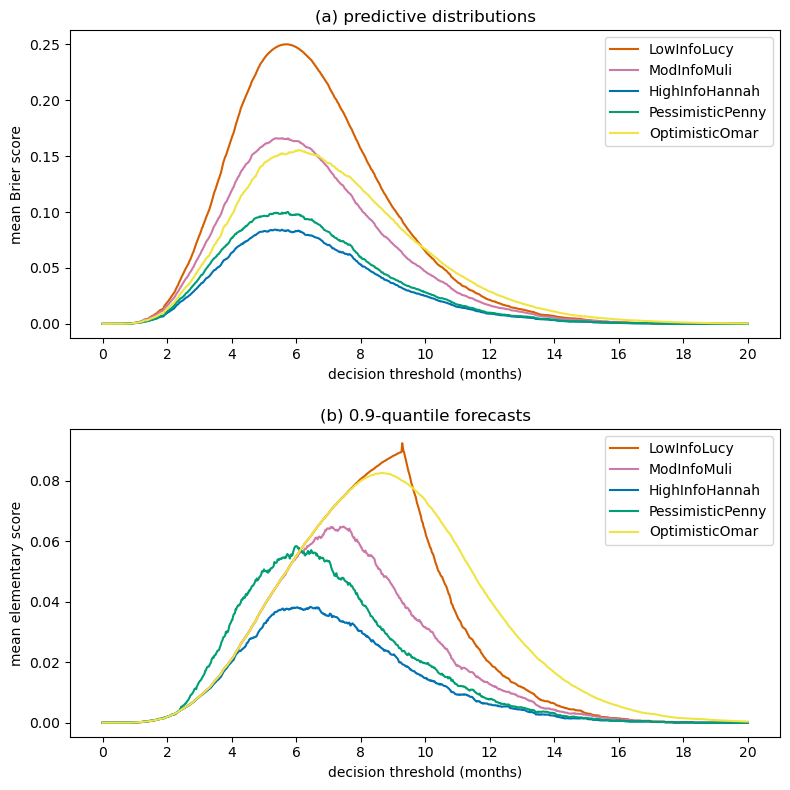

In [36]:
# values at which to compute curves along the x-axis
theta_values = np.linspace(0, 20, 1000)
thetas = xr.DataArray(data=theta_values, dims=['thld'], coords={'thld': theta_values})

# convert each time-to-event observation t into a binary observation relative to
# decision point theta
binary_obs = (t <= thetas).astype(float)

# location parameter for low info forecaster
loc_low = xr.zeros_like(t)

# broadcast variables to perform calculations
loc_low, loc_mid, loc_high, alpha_low, alpha_mid, alpha_high, thetas, binary_obs = broadcast_and_match_nan(
    loc_low, x, x + y, alpha_xyz, alpha_yz, alpha_z, thetas, binary_obs
)
thetas = thetas.transpose()

# calculate the thresholded probabilistic forecasts
prob_fcst_low = xr.ones_like(loc_low)
prob_fcst_low.values = gamma.cdf(thetas, alpha_low, scale=1/beta, loc=loc_low)
prob_fcst_mid = xr.ones_like(loc_low)
prob_fcst_mid.values = gamma.cdf(thetas, alpha_mid, scale=1/beta, loc=loc_mid)
prob_fcst_high = xr.ones_like(loc_low)
prob_fcst_high.values = gamma.cdf(thetas, alpha_high, scale=1/beta, loc=loc_high)
prob_fcst_pessimist = xr.ones_like(loc_low)
prob_fcst_pessimist.values = gamma.cdf(thetas, alpha_high, scale=1/beta_pessimist, loc=loc_high)
prob_fcst_optimist = xr.ones_like(loc_low)
prob_fcst_optimist.values = gamma.cdf(thetas, alpha_high, scale=1/beta_optimist, loc=loc_high)



# calculate scores for the decomposition and plot them
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# calculate and plot the Brier score for the thresholded probabilistic forecasts
prob_fcsts = [prob_fcst_low, prob_fcst_mid, prob_fcst_high, prob_fcst_pessimist, prob_fcst_optimist]
for fcst, idx in zip(prob_fcsts, range(5)):
    bs = brier_score(fcst, binary_obs, reduce_dims='case')
    ax1.plot(theta_values, bs.values,
             lw=linwid, alpha=opa, label=FCST_NAMES[idx], color=cp[idx])

    
# get the quantile forecasts in xarray format
q_fcsts = [xr.DataArray(data=fcst, dims=['case'], coords={'case': range(n)}) for fcst in q90_fcsts]    
# calculate and plot the mean elementary scores
for fcst, idx in zip(q_fcsts, range(5)):
    ms = murphy_score(fcst, t, theta_values, functional="quantile", alpha=0.9)['total']
    ax2.plot(theta_values, ms.values,
             lw=linwid, alpha=opa, label=FCST_NAMES[idx], color=cp[idx])
    

    
ax1.legend()
ax2.legend()
xticks = [2*x for x in range(11)]
ax1.set_xticks(xticks)
ax1.tick_params(axis='x', labelbottom=True)

ax1.set_title('(a) predictive distributions')
ax1.set_ylabel('mean Brier score')
ax1.set_xlabel("decision threshold (months)")

ax2.set_title('(b) 0.9-quantile forecasts')
ax2.set_ylabel('mean elementary score')
ax2.set_xlabel("decision threshold (months)")

fig.tight_layout(h_pad=2)

plt.show()